# 신경망 설계

## 환경설정

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris, load_diabetes, load_breast_cancer
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error, r2_score
from sklearn.svm import SVC, SVR
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense
from matplotlib import pyplot as plt

# BC 데이터를 통한 실습

In [6]:
# 실습 1-0 데이터 불러오기

bc = load_breast_cancer()
x_train, x_test, y_train, y_test = train_test_split(bc.data, 
                                                    bc.target, 
                                                    stratify=bc.target,
                                                    random_state=20260707)

scaler = StandardScaler()
x_train_zs = scaler.fit_transform(x_train)
x_test_zs = scaler.transform(x_test)
print(f"x_train shape: {x_train_zs.shape}, x_test shape: {y_test.shape}")

x_train shape: (426, 30), x_test shape: (143,)


In [13]:
def learning_plot(hist):
    plt.figure(figsize=(12, 5)) # 그래프 틀
    
    # 오차(Loss) 그래프 - 줄어들수록 좋음
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['loss'], label='train')
    plt.plot(hist.history['val_loss'], label='test')
    plt.legend(loc='best') # 범례
    plt.grid()             # 모눈종이 처리
    plt.title('Loss')
    plt.xlabel('Epoch')
    
    # 정확도(Accuracy) 그래프 - 올라갈수록 좋음
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['accuracy'], label='train')
    plt.plot(hist.history['val_accuracy'], label='test')
    plt.legend(loc='best')
    plt.grid()             # 모눈종이 처리
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    
    plt.show()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,337 (16.94 KB)

 Trainable params: 4,337 (16.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.3732 - loss: 0.2944 - val_accuracy: 0.3706 - val_loss: 0.2913
Epoch 2/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3732 - loss: 0.2879 - val_accuracy: 0.3706 - val_loss: 0.2852
Epoch 3/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3732 - loss: 0.2821 - val_accuracy: 0.3706 - val_loss: 0.2797
Epoch 4/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3732 - loss: 0.2769 - val_accuracy: 0.3706 - val_loss: 0.2745
Epoch 5/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.3732 - loss: 0.2720 - val_accuracy: 0.3706 - val_loss: 0.2699
Epoch 6/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3732 - loss: 0.2677 - val_accuracy: 0.3706 - val_loss: 0.2658
Epoch 7/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3732 - loss: 0.2637 - val_accuracy: 0.3706 - val_loss: 0.2618
Epoch 8/1000
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3732 - loss: 0.2601 - val_accu

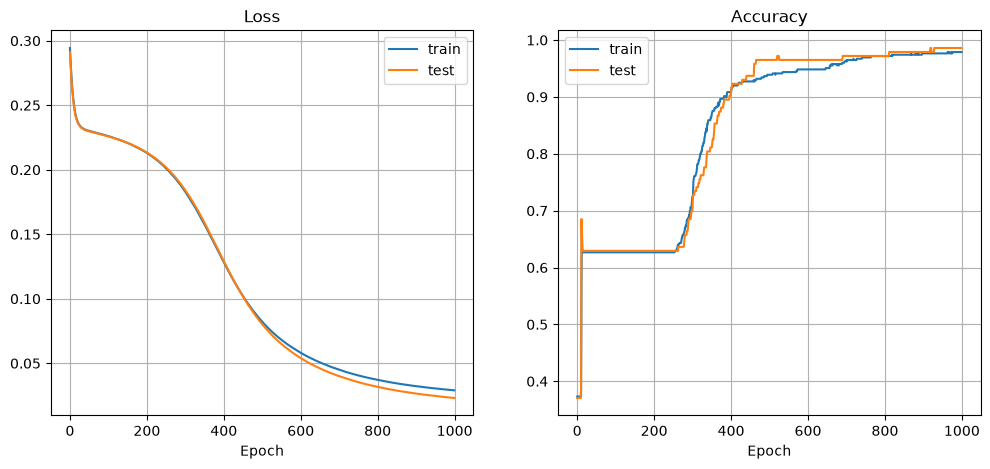

In [ ]:
# 실습 1-1 모델 적용(MSE 적용)

# 신경망 모델 설계
model = Sequential()
model.add(Input(shape=(x_train_zs.shape[1],)))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(32, activation='sigmoid'))
model.add(Dense(8, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# 모델 학습 규칙
model.compile(loss='mse', 
              optimizer='sgd',
              metrics=['accuracy'])

# 학습 진행
hist = model.fit(x_train_zs, y_train, 
                 validation_data=(x_test_zs, y_test), # 모의고사 데이터
                 epochs=1000)

learning_plot(hist)

## 모델 피드백

mse 의 경우 : 오차가 클수록 페널티가 있으나, 현재 모델의 경우 0~1 값이기 때문에 오히려 학습하기 어려움 // W = w + lr*E*dw


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,337 (16.94 KB)

 Trainable params: 4,337 (16.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3732 - loss: 0.5142 - val_accuracy: 0.3706 - val_loss: 0.5129
Epoch 2/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3732 - loss: 0.5118 - val_accuracy: 0.3706 - val_loss: 0.5108
Epoch 3/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.3732 - loss: 0.5097 - val_accuracy: 0.3706 - val_loss: 0.5083
Epoch 4/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3732 - loss: 0.5072 - val_accuracy: 0.3706 - val_loss: 0.5060
Epoch 5/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.3685 - loss: 0.5049 - val_accuracy: 0.3497 - val_loss: 0.5037
Epoch 6/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3404 - loss: 0.5027 - val_accuracy: 0.3986 - val_loss: 0.5012
Epoch 7/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4953 - loss: 0.5002 - val_accuracy: 0.6154 - val_loss: 0.4988
Epoch 8/700
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6291 - loss: 0.4979 - val_accuracy: 0.

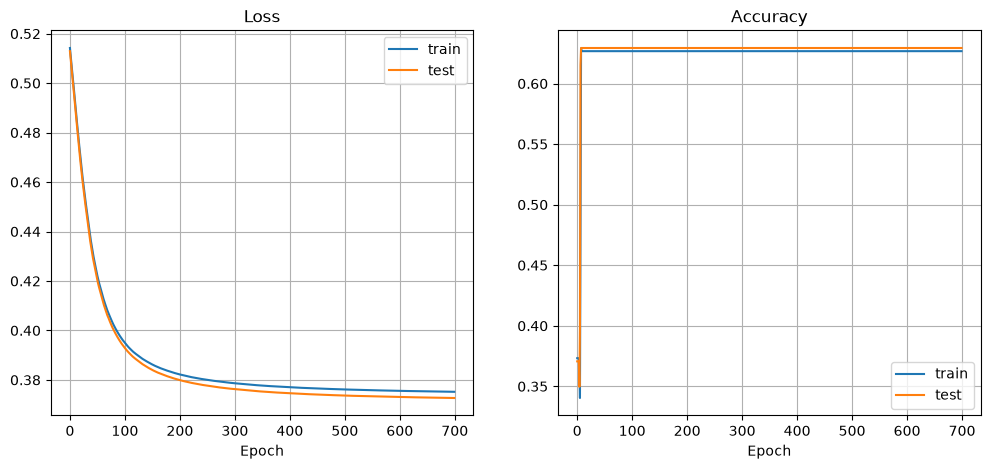

In [ ]:
# 실습 1-2 모델 적용(mae 적용)

# 신경망 모델 설계
model = Sequential()
model.add(Input(shape=(x_train_zs.shape[1],)))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(32, activation='sigmoid'))
model.add(Dense(8, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# 모델 학습 규칙
model.compile(loss='mae', 
              optimizer='sgd',
              metrics=['accuracy'])

# 학습 진행
hist = model.fit(x_train_zs, y_train, 
                 validation_data=(x_test_zs, y_test), # 모의고사 데이터
                 epochs=700)

learning_plot(hist)

## 모델 피드백

mae 의 경우 : 절댓값으로 좀 더 빠르게 최적의 결과가 나옴

## 모델 개선안
'binary_crossentropy'

-y = log(y^) -(1-y)=log(1-y^) : 정답 맞추면 0이됨 // 틀리면 무한대 수렴

제곱의 경우와 함께 사용

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,337 (16.94 KB)

 Trainable params: 4,337 (16.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.3732 - loss: 0.7231 - val_accuracy: 0.3706 - val_loss: 0.7109
Epoch 2/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.3732 - loss: 0.7028 - val_accuracy: 0.3706 - val_loss: 0.6946
Epoch 3/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4977 - loss: 0.6886 - val_accuracy: 0.9021 - val_loss: 0.6823
Epoch 4/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7629 - loss: 0.6781 - val_accuracy: 0.6294 - val_loss: 0.6736
Epoch 5/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6268 - loss: 0.6704 - val_accuracy: 0.6294 - val_loss: 0.6670
Epoch 6/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6268 - loss: 0.6648 - val_accuracy: 0.6294 - val_loss: 0.6615
Epoch 7/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6268 - loss: 0.6601 - val_accuracy: 0.6294 - val_loss: 0.6580
Epoch 8/400
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6268 - loss: 0.6570 - val_accuracy: 0.

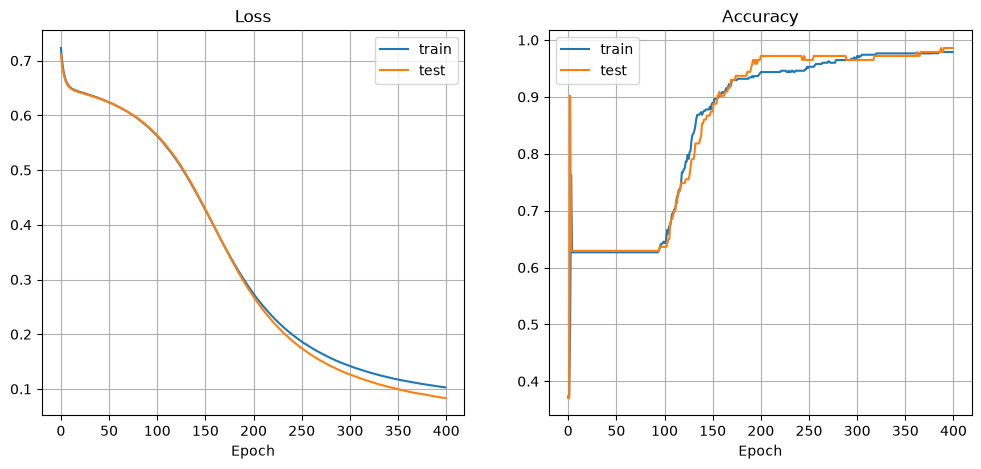

In [17]:
# 실습 1-3 모델 적용(binary_crossentropy 적용)

# 신경망 모델 설계
model = Sequential()
model.add(Input(shape=(x_train_zs.shape[1],)))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(32, activation='sigmoid'))
model.add(Dense(8, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# 모델 학습 규칙
model.compile(loss='binary_crossentropy',
              optimizer='sgd',
              metrics=['accuracy'])

# 학습 진행
hist = model.fit(x_train_zs, y_train, 
                 validation_data=(x_test_zs, y_test), # 모의고사 데이터
                 epochs=400)

learning_plot(hist)

## 모델 피드백

binary_crossentropy 의 경우 : 더 빠르게 최적의 결과가 나옴 // 확률값을 도출하는 경우 사용

## 모델 개선안
'sgd' -> 'Adam'

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_28 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,337 (16.94 KB)

 Trainable params: 4,337 (16.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3732 - loss: 0.7524 - val_accuracy: 0.3706 - val_loss: 0.6921
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7277 - loss: 0.6599 - val_accuracy: 0.6434 - val_loss: 0.6336
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6479 - loss: 0.6124 - val_accuracy: 0.6364 - val_loss: 0.5967
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6737 - loss: 0.5767 - val_accuracy: 0.7133 - val_loss: 0.5586
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7793 - loss: 0.5347 - val_accuracy: 0.7972 - val_loss: 0.5120
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8685 - loss: 0.4858 - val_accuracy: 0.8881 - val_loss: 0.4615
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9178 - loss: 0.4352 - val_accuracy: 0.9301 - val_loss: 0.4087
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9366 - loss: 0.3880 - val_accuracy: 0.

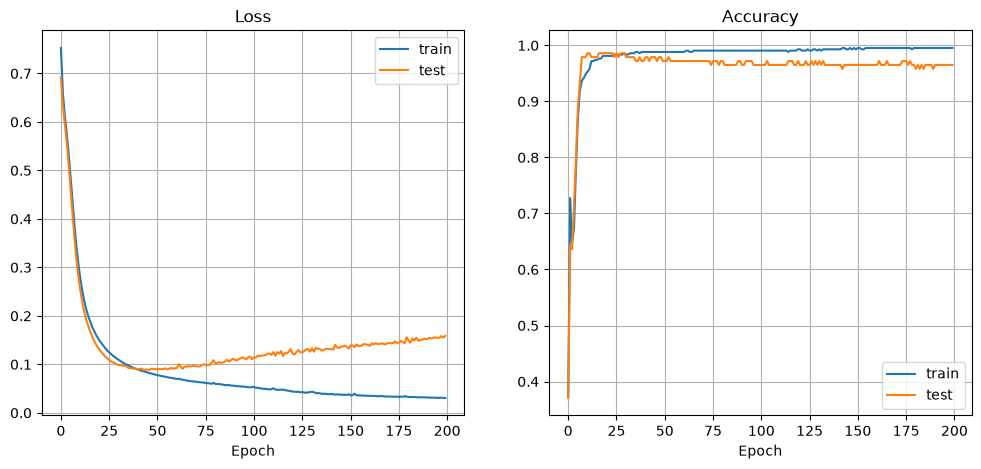

In [18]:
# 실습 1-4 모델 적용(adam 적용)

# 신경망 모델 설계
model = Sequential()
model.add(Input(shape=(x_train_zs.shape[1],)))
model.add(Dense(64, activation='sigmoid'))
model.add(Dense(32, activation='sigmoid'))
model.add(Dense(8, activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# 모델 학습 규칙
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 학습 진행
hist = model.fit(x_train_zs, y_train, 
                 validation_data=(x_test_zs, y_test), # 모의고사 데이터
                 epochs=200)

learning_plot(hist)

## 모델 개선안
은닉측 sigmoid -> relu

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,337 (16.94 KB)

 Trainable params: 4,337 (16.94 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.8052 - loss: 0.5355 - val_accuracy: 0.9441 - val_loss: 0.4065
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9390 - loss: 0.3109 - val_accuracy: 0.9510 - val_loss: 0.2398
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9531 - loss: 0.1920 - val_accuracy: 0.9580 - val_loss: 0.1485
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9577 - loss: 0.1372 - val_accuracy: 0.9790 - val_loss: 0.1041
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9624 - loss: 0.1082 - val_accuracy: 0.9790 - val_loss: 0.0796
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9789 - loss: 0.0920 - val_accuracy: 0.9790 - val_loss: 0.0651
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9765 - loss: 0.0809 - val_accuracy: 0.9790 - val_loss: 0.0568
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9789 - loss: 0.0733 - val_accuracy: 0.9860 - v

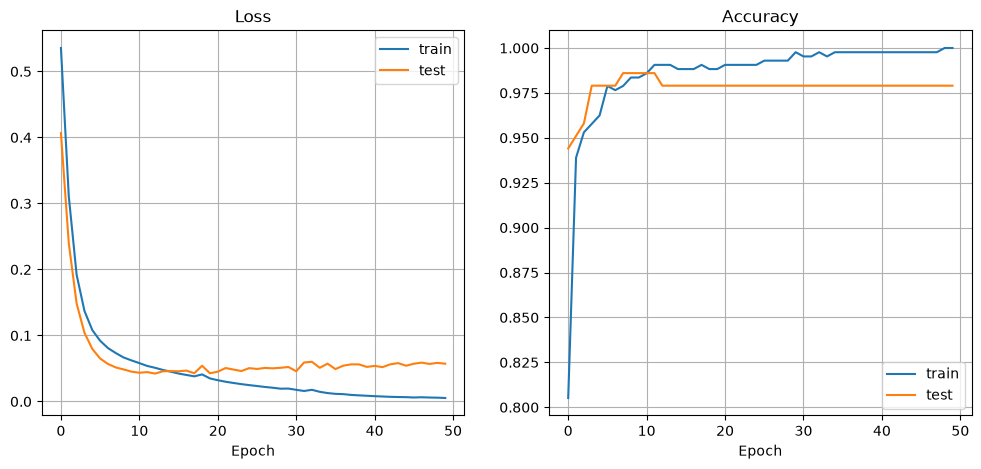

In [19]:
# 실습 1-5 모델 적용(relu 적용)

# 신경망 모델 설계
model = Sequential()
model.add(Input(shape=(x_train_zs.shape[1],)))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

# 모델 학습 규칙
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# 학습 진행
hist = model.fit(x_train_zs, y_train, 
                 validation_data=(x_test_zs, y_test), # 모의고사 데이터
                 epochs=50)

learning_plot(hist)

## 1. 활성화 함수 (Activation): ReLU vs Sigmoid

활성화 함수는 이전 층에서 넘어온 데이터를 어떤 형태로 변환해서 넘길지 결정하는 역할을 합니다.

### 1) Sigmoid (시그모이드)

- **특징**: 모든 숫자를 0과 1 사이의 부드러운 곡선으로 압축. 음수는 0에 가깝게, 양수는 1에 가깝게 만듭니다.
- **용도**: 결과값이 0~1 사이의 '확률'로 나와야 하는 이진 분류.
- **단점 (은닉층에서 안 쓰는 이유)**: 신경망이 깊어질수록 값을 계속 0~1 사이로 짓누르다 보니, 나중에는 데이터의 특징(기울기)이 희미해져서 학습이 멈춰버리는 **기울기 소실(Vanishing Gradient)** 발생.

### 2) ReLU (렐루, Rectified Linear Unit)

- **특징**: 단순. 음수면 그냥 0으로 없애버리고, 양수면 그 숫자 그대로 통과시킴 (`max(0, x)`).
- **용도**: 은닉층(Hidden Layer)의 표준(Standard). 특별한 이유가 없다면 ReLU를 사용.
- **장점**: 계산 속도가 엄청나게 빠르고, 기울기 소실 문제를 완벽하게 해결하여 신경망을 수십, 수백 층으로 쌓을 수 있게 함.

---

## 2. 손실 함수 (Loss): MSE vs Binary Crossentropy 등

손실 함수는 모델이 정답을 맞히고 나서 채점하는 오차 계산법입니다.

### 1) MSE (Mean Squared Error, 평균 제곱 오차)

- **사용 시기**: 회귀 문제 (집값 예측, 온도 예측 등 구체적인 연속된 '숫자'를 맞힐 때)
- **특징**: 실제 정답 수치와 모델이 예측한 수치의 차이를 제곱하여 평균을 냅니다. 오차가 클수록 페널티를 기하급수적으로 크게 주기 때문에, 이상치(Outlier)에 아주 민감하게 반응합니다.

### 2) MAE (Mean Absolute Error, 평균 절대 오차)

- **사용 시기**: 회귀 문제 (MSE와 마찬가지로 구체적인 연속된 '숫자'를 맞힐 때)
- **특징**: 실제 정답 수치와 모델이 예측한 수치의 차이에 절대값을 씌워 평균을 냅니다. 오차가 커져도 제곱하지 않고 오차 크기 그대로 정직하게 반영하기 때문에, 이상치(Outlier)의 영향에 비교적 덜 흔들리고 강건(Robust)하다는 장점이 있습니다.

### 3) Binary Crossentropy (이진 교차 엔트로피)

- **사용 시기**: 이진 분류 문제 (암 양성/악성, 스팸메일 O/X 등 2개 중 하나를 고를 때)
- **특징**: 확률 기반. 정답이 1(암)인데 모델이 0.1(10%)이라고 예측했다면 큰 페널티를, 0.9(90%)라고 예측했다면 작은 벌점을 줍니다.

### 4) Categorical Crossentropy (다중 교차 엔트로피) — 번외

- **사용 시기**: 다중 분류 문제 (개/고양이/새 중 하나 맞히기, 아이리스 꽃 3종류 분류 등 정답이 3개 이상일 때)
- **특징**: 확률 기반 채점 방식입니다. 여러 개의 선택지 중에서 모델이 제출한 정답 확률 분포가 실제 정답(원-핫 인코딩 형태)과 얼마나 일치하는지 비교하여 오차를 계산합니다.

---

## 3. 최적화 알고리즘 (Optimizer): SGD vs Adam

최적화 알고리즘은 손실 함수로 계산된 오차를 바탕으로 어떻게 하면 가장 빠르고 안전하게 오차를 0(최적의 가중치)으로 줄여나갈지 결정하는 엔진입니다.

### 1) SGD (Stochastic Gradient Descent, 확률적 경사 하강법)

- **특징**: 가장 기본적이고 고전적인 방식. 현재 서 있는 위치에서 경사(기울기)가 제일 가파른 쪽으로 지정된 단위씩 정직하게 내려갑니다.
- **단점**: 보폭(학습률)이 고정되어 있어서 복잡한 데이터에서는 이리저리 튀거나, 움푹 파인 특정 최소값(Local Minima)으로 길을 잃는 경우가 발생. 속도도 느림.

### 2) Adam (Adaptive Moment Estimation)

- **특징**: 현재 딥러닝계의 압도적인 방식. 관성(Momentum)과 적응적 학습률(Adaptive, 경사가 완만하면 보폭을 크게, 가파르면 보폭을 작게 조절) 두 가지 고급 기술을 모두 합친 알고리즘.
- **장점**: 방향을 잃지 않고 아주 부드럽고 빠르게 최적점을 찾아갑니다. 실무에서는 무조건 `optimizer='adam'`을 기본값으로 깔고 시작합니다.